# 02E: Multi-Horizon Log-Return Forecasting

Extends **02D** (cluster-news enhanced short-horizon signal) to medium-term horizons by predicting
**forward log returns** simultaneously at T+5, T+10, and T+15 trading days.

## Design overview
| Design decision | Rationale |
|---|---|
| Log returns, not prices | Stationarity; additive across horizons; comparable across price levels |
| Direct multi-output (not recursive) | Avoids error propagation T+5→T+10→T+15 |
| 32+ features (02C base + 02E trend + 02D cluster-news composite) | Preserve comparability while injecting richer news structure |
| Cluster-aware training | One MultiOutputRegressor per K-Means peer group |
| 80/20 temporal split + 22-day buffer | Prevents target leakage from 15-day forward window |

## Implementation modes (new vs legacy)
1. **New (recommended)**: use 02D full-universe clustered-news outputs as the primary sentiment input.
2. **Legacy fallback**: if new 02D artifacts are missing, fallback to older 02C/03A files.
3. **Safety fallback**: if both are missing, recompute lightweight clustering from price features.

## Output files
- `02E_multi_horizon_predictions.csv` — full prediction table
- `02E_model_performance.csv` — MAE/RMSE/R²/DHR per stock per horizon
- `02E_feature_importance.csv` — averaged feature importance across 3 output models
- `02E_trend_features.csv` — full feature dataset


In [50]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn xgboost lightgbm kagglehub yfinance transformers torch scipy



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [51]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binomtest

from sklearn.cluster import KMeans
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

import kagglehub
import yfinance as yf

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.6f}'.format)
np.random.seed(42)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titleweight'] = 'bold'

# ── Config ─────────────────────────────────────────────────────────
# Use full universe by default to align with new 02D full-universe clustering.
FAST_MODE  = False
FAST_STOCKS = ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'NVDA']

HORIZONS   = [5, 10, 15]   # forward-return windows (trading days)
CLIP_LR    = 0.30           # clip log returns to ±30 %
SPLIT_FRAC = 0.80           # 80 % train, 20 % test
BUFFER_DAYS = 22            # ≥15 trading-day buffer after train/test cut
N_CLUSTERS  = 6             # fallback K-Means clusters

# New 02D integration switches
USE_02D_CLUSTERNEWS_PRIMARY = True
USE_02D_DYNAMIC_CLUSTER_PRIMARY = True

# ── NEW: Per-horizon XGB parameter tuning ──────────────────────────
# Shorter horizons can be more aggressive; longer horizons need conservatism
XGB_PARAMS_BASE = dict(
    n_estimators=500,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    eval_metric='mae',
)

# Per-horizon parameter overrides (reduces conservatism progressively)
XGB_PARAMS_BY_HORIZON = {
    5: {
        **XGB_PARAMS_BASE,
        'max_depth': 5,
        'min_child_weight': 3,   # Slightly aggressive for short-term
        'subsample': 0.90,
    },
    10: {
        **XGB_PARAMS_BASE,
        'max_depth': 6,
        'min_child_weight': 4,   # Moderate
        'subsample': 0.87,
    },
    15: {
        **XGB_PARAMS_BASE,
        'max_depth': 7,
        'min_child_weight': 6,   # More conservative for long-term
        'subsample': 0.83,
    },
}

print('[OK] Config loaded with per-horizon parameter tuning')
print(f'FAST_MODE={FAST_MODE}')
print(f'Horizons: {HORIZONS}')
print(f'Per-horizon max_depth: {[XGB_PARAMS_BY_HORIZON[h]["max_depth"] for h in HORIZONS]}')

[OK] Config loaded with per-horizon parameter tuning
FAST_MODE=False
Horizons: [5, 10, 15]
Per-horizon max_depth: [5, 6, 7]


In [52]:
# ── Path resolution (same pattern as 02C / 02D) ──────────────────
cwd = Path.cwd()
if cwd.name == 'implementation' and cwd.parent.name == '02_stock_price_regression':
    reg_root = cwd.parent
elif cwd.name == '02_stock_price_regression':
    reg_root = cwd
elif (cwd / 'project_folder' / '02_stock_price_regression').exists():
    reg_root = cwd / 'project_folder' / '02_stock_price_regression'
else:
    reg_root = cwd

workspace_root = reg_root.parent
data_dir  = reg_root / 'data'
graph_dir = reg_root / 'graph'
impl_dir  = reg_root / 'implementation'
data_dir.mkdir(parents=True, exist_ok=True)
graph_dir.mkdir(parents=True, exist_ok=True)

cluster_data_dir = workspace_root / '03_stock_clustering_analysis' / 'data'

print(f'Workspace : {workspace_root}')
print(f'Data dir  : {data_dir}')
print(f'Graph dir : {graph_dir}')


Workspace : /Users/yeechiu/Documents/GitHub/mobile-app-assignment-1/AI-Assignment-1/AI-assignment-2/ML-in-Finance-Data-Project/project_folder
Data dir  : /Users/yeechiu/Documents/GitHub/mobile-app-assignment-1/AI-Assignment-1/AI-assignment-2/ML-in-Finance-Data-Project/project_folder/02_stock_price_regression/data
Graph dir : /Users/yeechiu/Documents/GitHub/mobile-app-assignment-1/AI-Assignment-1/AI-assignment-2/ML-in-Finance-Data-Project/project_folder/02_stock_price_regression/graph


In [53]:
# ── Load price data ──────────────────────────────────────────────
price_candidates = [
    cluster_data_dir / 'sp500_raw.csv',
    data_dir / 'sp500_raw.csv',
    data_dir / '02C_sp500_raw.csv',
    data_dir / '02B_sp500_raw.csv',
]
price_path = next((p for p in price_candidates if p.exists()), None)

if price_path:
    raw = pd.read_csv(price_path)
    print(f'[CACHE] Loaded price data from {price_path.name}: {len(raw):,} rows')
else:
    print('[INFO] Downloading S&P 500 data from Kaggle …')
    kpath = kagglehub.dataset_download('camnugent/sandp500')
    csv_f = [f for f in os.listdir(kpath) if f.endswith('.csv')][0]
    raw   = pd.read_csv(os.path.join(kpath, csv_f))
    # cache for future runs
    raw.to_csv(data_dir / 'sp500_raw.csv', index=False)
    print(f'[OK] Downloaded: {len(raw):,} rows')

# Standardise column names (lowercase) for robustness
raw.columns = [c.strip() for c in raw.columns]
col_map = {c: c.lower() for c in raw.columns}
col_map.update({c: c for c in raw.columns if c in ('Name', 'date')})
raw.rename(columns=col_map, inplace=True)

# Ensure 'Name' column exists
if 'name' in raw.columns and 'Name' not in raw.columns:
    raw.rename(columns={'name': 'Name'}, inplace=True)

raw['date'] = pd.to_datetime(raw['date'], errors='coerce').dt.normalize()
raw = raw.dropna(subset=['Name', 'date']).sort_values(['Name', 'date']).reset_index(drop=True)

# Normalise Close column name
close_col = next((c for c in raw.columns if c.lower() == 'close'), None)
if close_col and close_col != 'Close':
    raw.rename(columns={close_col: 'Close'}, inplace=True)
for col_lc, col_uc in [('open','Open'),('high','High'),('low','Low'),('volume','Volume')]:
    if col_lc in raw.columns:
        raw.rename(columns={col_lc: col_uc}, inplace=True)

all_symbols = sorted(raw['Name'].unique())
if FAST_MODE:
    symbols = [s for s in FAST_STOCKS if s in set(all_symbols)]
else:
    symbols = all_symbols

price_df = raw[raw['Name'].isin(symbols)].copy()
print(f'Symbols used: {symbols}')
print(f'Price rows: {len(price_df):,}')
print(price_df.head(3))


[CACHE] Loaded price data from sp500_raw.csv: 619,040 rows
Symbols used: ['A', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABC', 'ABT', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADS', 'ADSK', 'AEE', 'AEP', 'AES', 'AET', 'AFL', 'AGN', 'AIG', 'AIV', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALK', 'ALL', 'ALLE', 'ALXN', 'AMAT', 'AMD', 'AME', 'AMG', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANDV', 'ANSS', 'ANTM', 'AON', 'AOS', 'APA', 'APC', 'APD', 'APH', 'APTV', 'ARE', 'ARNC', 'ATVI', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXP', 'AYI', 'AZO', 'BA', 'BAC', 'BAX', 'BBT', 'BBY', 'BDX', 'BEN', 'BF.B', 'BHF', 'BHGE', 'BIIB', 'BK', 'BLK', 'BLL', 'BMY', 'BRK.B', 'BSX', 'BWA', 'BXP', 'C', 'CA', 'CAG', 'CAH', 'CAT', 'CB', 'CBG', 'CBOE', 'CBS', 'CCI', 'CCL', 'CDNS', 'CELG', 'CERN', 'CF', 'CFG', 'CHD', 'CHK', 'CHRW', 'CHTR', 'CI', 'CINF', 'CL', 'CLX', 'CMA', 'CMCSA', 'CME', 'CMG', 'CMI', 'CMS', 'CNC', 'CNP', 'COF', 'COG', 'COL', 'COO', 'COP', 'COST', 'COTY', 'CPB', 'CRM', 'CSCO', 'CSRA', 'CSX', 'CTAS', 'CTL', 'CTSH', 'CTXS', 'CVS', 'CVX', 'C

In [54]:
# ── Cluster assignments ──────────────────────────────────────────
# Priority now follows new 02D implementation.
# 1) 02D dynamic cluster map (if exported)
# 2) 02D cluster-news feature space (name-level KMeans projection)
# 3) Legacy 02C/03A cluster files
# 4) Fallback recompute from price features

d02d_dynamic_cluster_path = data_dir / '02D_daily_cluster_map.csv'
d02d_news_feat_path = data_dir / '02D_cluster_news_features.csv'

cluster_df = None

if USE_02D_DYNAMIC_CLUSTER_PRIMARY and d02d_dynamic_cluster_path.exists():
    ctmp = pd.read_csv(d02d_dynamic_cluster_path)
    ctmp['Name'] = ctmp['Name'].astype(str).str.strip()
    if 'final_cluster' in ctmp.columns:
        mode_cluster = (
            ctmp.groupby('Name')['final_cluster']
            .agg(lambda s: s.mode().iloc[0] if len(s.mode()) > 0 else s.iloc[-1])
            .reset_index()
            .rename(columns={'final_cluster': 'sent_cluster'})
        )
        cluster_df = mode_cluster.copy()
        print(f'[02D] Loaded dynamic cluster map from {d02d_dynamic_cluster_path.name}')

if cluster_df is None and USE_02D_CLUSTERNEWS_PRIMARY and d02d_news_feat_path.exists():
    news_feat = pd.read_csv(d02d_news_feat_path)
    news_feat['Name'] = news_feat['Name'].astype(str).str.strip()
    usable_cols = [
        c for c in [
            'direct_sentiment_10d',
            'cluster_sentiment_10d',
            'macro_sentiment_10d',
            'news_intensity_10d',
            'cluster_news_count_10d',
            'avg_cosine_sim_10d',
            'news_imbalance_10d',
        ] if c in news_feat.columns
    ]
    if len(usable_cols) >= 3:
        proj = news_feat.groupby('Name')[usable_cols].mean().fillna(0.0).reset_index()
        n_k = min(N_CLUSTERS, max(2, len(proj) // 4))
        Xc = StandardScaler().fit_transform(proj[usable_cols])
        labels = KMeans(n_clusters=n_k, random_state=42, n_init=10).fit_predict(Xc)
        cluster_df = proj[['Name']].copy()
        cluster_df['sent_cluster'] = labels.astype(int)
        print(f'[02D] Built cluster projection from 02D news features ({n_k} clusters).')

if cluster_df is None:
    cluster_candidates = [
        data_dir / '02C_sentiment_kmeans_stock_assignments.csv',
        cluster_data_dir / '03A_stock_cluster_assignments.csv',
    ]
    cluster_src = next((p for p in cluster_candidates if p.exists()), None)

    if cluster_src:
        ctmp = pd.read_csv(cluster_src)
        ctmp['Name'] = ctmp['Name'].astype(str).str.strip()
        cluster_col = 'sent_cluster' if 'sent_cluster' in ctmp.columns else ('cluster' if 'cluster' in ctmp.columns else None)
        if cluster_col is not None:
            cluster_df = ctmp[['Name', cluster_col]].rename(columns={cluster_col: 'sent_cluster'}).drop_duplicates('Name')
            print(f'[LEGACY] Cluster assignments from {cluster_src.name}')

if cluster_df is None:
    print('[INFO] No cluster file found – computing K-Means on return features …')

    def build_cluster_features(df):
        feat = (
            df.groupby('Name')['Close']
            .apply(lambda x: pd.Series({
                'volatility':     x.pct_change().std(),
                'avg_return':     x.pct_change().mean(),
                'momentum':       x.iloc[-1] / x.iloc[0] - 1 if len(x) > 1 else 0,
                'trend_strength': x.diff().gt(0).mean(),
                'price_level':    x.mean(),
            }))
        )
        return feat.reset_index()

    feat_df  = build_cluster_features(price_df[price_df['Name'].isin(symbols)])
    scaler_c = StandardScaler()
    Xc       = scaler_c.fit_transform(feat_df[['volatility', 'avg_return', 'momentum', 'trend_strength', 'price_level']].fillna(0))
    labels   = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10).fit_predict(Xc)
    cluster_df = feat_df[['Name']].copy()
    cluster_df['sent_cluster'] = labels

cluster_map = dict(zip(cluster_df['Name'], cluster_df['sent_cluster']))
price_df['cluster'] = price_df['Name'].map(cluster_map).fillna(0).astype(int)
print(price_df.groupby(['Name', 'cluster']).size().reset_index(name='rows'))

[02D] Built cluster projection from 02D news features (6 clusters).
     Name  cluster  rows
0       A        5  1259
1     AAL        4  1259
2     AAP        5  1259
3    AAPL        2  1259
4    ABBV        1  1259
..    ...      ...   ...
500   XYL        5  1259
501   YUM        2  1259
502   ZBH        1  1259
503  ZION        5  1259
504   ZTS        1  1259

[505 rows x 3 columns]


In [55]:
# ── Time-Aware Dynamic Clustering (NEW) ─────────────────────────
# Instead of static cluster assignments, compute cluster membership *per date*
# based on rolling return characteristics. This captures market dynamics better.

print('[NEW] Building time-aware dynamic clustering …')

TIME_AWARE_CLUSTER = True  # Toggle: set False to revert to static clustering
CLUSTER_REBALANCE_DAYS = 20  # Rebalance clusters every 20 trading days

if TIME_AWARE_CLUSTER:
    # First, establish the set of unique dates
    all_dates_sorted = sorted(price_df['date'].unique())
    print(f'  Date range: {all_dates_sorted[0]} to {all_dates_sorted[-1]} ({len(all_dates_sorted)} trading dates)')
    
    # Pre-compute rolling features for each date; we'll cluster based on recent returns
    dynamic_cluster_map = {}  # {date: {stock: cluster_id}}
    
    for idx, date in enumerate(all_dates_sorted):
        # Use 60-day lookback window for clustering
        lookback_start = date - pd.Timedelta(days=60)
        lookback_df = price_df[(price_df['date'] >= lookback_start) & (price_df['date'] <= date)]
        
        if len(lookback_df) == 0:
            continue
        
        # Compute return-based features for this window
        cluster_features = []
        for stock in symbols:
            stock_data = lookback_df[lookback_df['Name'] == stock].sort_values('date')
            if len(stock_data) < 10:  # Not enough data
                continue
            
            close_vals = stock_data['Close'].values
            returns = np.diff(np.log(close_vals))
            
            feat_dict = {
                'Name': stock,
                'date': date,
                'ret_mean': returns.mean(),
                'ret_vol': returns.std(),
                'ret_skew': pd.Series(returns).skew() if len(returns) > 3 else 0,
                'momentum': close_vals[-1] / close_vals[0] - 1 if len(close_vals) > 1 else 0,
            }
            cluster_features.append(feat_dict)
        
        if len(cluster_features) < 5:  # Not enough stocks for meaningful clustering
            continue
        
        feat_frame = pd.DataFrame(cluster_features)
        scaler_dyn = StandardScaler()
        X_dyn = scaler_dyn.fit_transform(
            feat_frame[['ret_mean', 'ret_vol', 'ret_skew', 'momentum']].fillna(0)
        )
        
        # Adaptive cluster count: use fewer clusters on dates with fewer valid stocks
        n_clusters_dyn = min(N_CLUSTERS, max(2, len(feat_frame) // 8))
        km_dyn = KMeans(n_clusters=n_clusters_dyn, random_state=42, n_init=5)
        labels_dyn = km_dyn.fit_predict(X_dyn)
        
        # Store mapping for this date
        daily_map = dict(zip(feat_frame['Name'], labels_dyn))
        dynamic_cluster_map[date] = daily_map
        
        if idx % max(1, len(all_dates_sorted) // 5) == 0:
            print(f'    {date.date()}: {len(daily_map)} stocks clustered into {n_clusters_dyn} groups')
    
    print(f'  Dynamic clusters computed for {len(dynamic_cluster_map)} dates')
    
    # Now apply dynamic clusters to price_df
    def get_daily_cluster(row):
        """Look up cluster for this (date, stock) pair from dynamic map."""
        date = row['date']
        stock = row['Name']
        
        # If exact date not in map, find the nearest prior date
        if date in dynamic_cluster_map:
            return dynamic_cluster_map[date].get(stock, 0)
        else:
            prior_dates = [d for d in dynamic_cluster_map.keys() if d <= date]
            if prior_dates:
                nearest = max(prior_dates)
                return dynamic_cluster_map[nearest].get(stock, 0)
            else:
                return 0
    
    price_df['cluster'] = price_df.apply(get_daily_cluster, axis=1)
    print(f'[OK] Time-aware clustering applied. Unique (date, cluster) combinations: {price_df.groupby(["date","cluster"]).size().shape[0]}')

else:
    print('[INFO] TIME_AWARE_CLUSTER=False, reverting to static cluster mapping')
    price_df['cluster'] = price_df['Name'].map(cluster_map).fillna(0).astype(int)

[NEW] Building time-aware dynamic clustering …
  Date range: 2013-02-08 00:00:00 to 2018-02-07 00:00:00 (1259 trading dates)
    2014-02-07: 483 stocks clustered into 6 groups
    2015-02-06: 489 stocks clustered into 6 groups
    2016-02-05: 496 stocks clustered into 6 groups
    2017-02-03: 500 stocks clustered into 6 groups
    2018-02-02: 505 stocks clustered into 6 groups
  Dynamic clusters computed for 1250 dates
[OK] Time-aware clustering applied. Unique (date, cluster) combinations: 7509


In [58]:
# ── Load pre-computed sentiment scores (new 02D primary) ─────────
# PRIORITY ORDER:
#   1. 02D_cluster_news_features.csv  — full-universe cluster-news outputs (preferred)
#   2. 02C_daily_sentiment_scores.csv — legacy single-layer sentiment
#   3. Zero placeholder                — safety fallback

sentiment_candidates = [
    data_dir / '02D_cluster_news_features.csv',
    data_dir / '02C_daily_sentiment_scores.csv',
]
sentiment_src = next((p for p in sentiment_candidates if p.exists()), None)

if sentiment_src:
    sent_raw = pd.read_csv(sentiment_src)
    sent_raw['date'] = pd.to_datetime(sent_raw['date'], errors='coerce').dt.normalize()
    sent_raw['Name'] = sent_raw['Name'].astype(str).str.strip()

    # New 02D composite sentiment (direct + cluster + macro).
    if USE_02D_CLUSTERNEWS_PRIMARY and sentiment_src.name == '02D_cluster_news_features.csv':
        needed = ['direct_sentiment_10d', 'cluster_sentiment_10d', 'macro_sentiment_10d']
        if all(c in sent_raw.columns for c in needed):
            sent_raw['raw_sentiment'] = (
                0.50 * sent_raw['direct_sentiment_10d'].fillna(0.0)
                + 0.35 * sent_raw['cluster_sentiment_10d'].fillna(0.0)
                + 0.15 * sent_raw['macro_sentiment_10d'].fillna(0.0)
            )
            if 'news_intensity_10d' in sent_raw.columns:
                sent_raw['raw_sentiment'] = sent_raw['raw_sentiment'] * (1.0 + 0.10 * sent_raw['news_intensity_10d'].fillna(0.0))
            
            # ─── NEW: Carry-forward logic ───────────────────────────────
            # When a stock has zero sentiment on a day, carry forward the last
            # non-zero sentiment signal for up to 3 days (decay it exponentially).
            sent_raw = sent_raw.sort_values(['Name', 'date']).reset_index(drop=True)
            def apply_carry_forward(group, lookback_days=3, decay_factor=0.85):
                """Carry forward non-zero sentiment for up to lookback_days, with exponential decay."""
                group = group.reset_index(drop=True).copy()  # Ensure clean position-based indexing
                for pos in range(len(group)):
                    if group.iloc[pos]['raw_sentiment'] == 0.0:
                        # Look back up to lookback_days using position-based indexing
                        for j in range(1, lookback_days + 1):
                            if pos - j >= 0:
                                prev_val = group.iloc[pos - j]['raw_sentiment']
                                if prev_val != 0.0:
                                    decay = decay_factor ** j
                                    group.iat[pos, group.columns.get_loc('raw_sentiment')] = prev_val * decay
                                    break
                return group
            
            sent_raw = sent_raw.groupby('Name', group_keys=False).apply(apply_carry_forward)
            print(f'[UPGRADE] Applied carry-forward to sentiment gaps (up to 3 days, decay=0.85)')
            
            # ─── NEW: Coverage gating ──────────────────────────────────
            # Calculate coverage ratio per stock and use it to scale sentiment importance.
            # Stocks with low news coverage should have sentiment dampened.
            if 'news_intensity_10d' in sent_raw.columns:
                coverage = sent_raw.groupby('Name')['news_intensity_10d'].apply(
                    lambda x: (x > 0).sum() / len(x) if len(x) > 0 else 0.0
                ).reset_index()
                coverage.columns = ['Name', 'coverage_ratio']
                sent_raw = sent_raw.merge(coverage, on='Name', how='left')
                sent_raw['coverage_ratio'] = sent_raw['coverage_ratio'].fillna(0.0)
                
                # Apply gating: when coverage is low, reduce sentiment weight
                COVERAGE_THRESHOLD = 0.05  # 5% minimum coverage
                coverage_gate = np.where(
                    sent_raw['coverage_ratio'] >= COVERAGE_THRESHOLD,
                    1.0,  # Full weight if coverage sufficient
                    sent_raw['coverage_ratio'] / COVERAGE_THRESHOLD  # Scale down if below threshold
                )
                sent_raw['raw_sentiment'] = sent_raw['raw_sentiment'] * coverage_gate
                print(f'[UPGRADE] Applied coverage gating (threshold={COVERAGE_THRESHOLD:.1%})')
                sent_raw = sent_raw.drop(columns=['coverage_ratio'])
            
            sent_sub = sent_raw[['Name', 'date', 'raw_sentiment']].copy()
            source_note = '02D composite (direct/cluster/macro) + carry-forward + coverage gating'
        else:
            sent_sub = sent_raw[['Name', 'date']].copy()
            sent_sub['raw_sentiment'] = 0.0
            source_note = '02D file found but key columns missing (fallback zeros)'
    else:
        col_preference = [
            'sentiment_score',
            'direct_sentiment_10d',
            'cluster_sentiment_10d',
            'macro_sentiment_10d',
        ]
        chosen_col = next((c for c in col_preference if c in sent_raw.columns), None)
        if chosen_col is not None:
            sent_sub = sent_raw[['Name', 'date', chosen_col]].rename(columns={chosen_col: 'raw_sentiment'})
            source_note = f'legacy column={chosen_col}'
        else:
            sent_sub = sent_raw[['Name', 'date']].copy()
            sent_sub['raw_sentiment'] = 0.0
            source_note = 'no usable column (fallback zeros)'

    sent_sub = sent_sub.dropna(subset=['Name', 'date']).copy()
    non_zero_rate = (sent_sub['raw_sentiment'].fillna(0) != 0).mean()
    print(f'[OK] Sentiment loaded from {sentiment_src.name} | {source_note}')
    print(f'     Non-zero rows: {non_zero_rate:.1%} of {len(sent_sub):,}')
    sent_raw = sent_sub
else:
    print('[WARN] No sentiment file found — creating zero-sentiment placeholder')
    date_range = pd.date_range(price_df['date'].min(), price_df['date'].max(), freq='B')
    sent_raw = pd.MultiIndex.from_product(
        [symbols, date_range], names=['Name', 'date']
    ).to_frame(index=False)
    sent_raw['raw_sentiment'] = 0.0

price_df = price_df.merge(sent_raw, on=['Name', 'date'], how='left')
price_df['raw_sentiment'] = price_df['raw_sentiment'].fillna(0.0)

non_zero = (price_df['raw_sentiment'] != 0).sum()
print(f'Non-zero sentiment rows in price_df: {non_zero:,} / {len(price_df):,} ({non_zero/len(price_df):.1%})')
if non_zero == 0:
    print('[WARN] All sentiment values are zero — sentiment features will have zero importance.')
    print('       To fix: run 02D precompute + Step 3 first to generate populated sentiment scores.')

[UPGRADE] Applied carry-forward to sentiment gaps (up to 3 days, decay=0.85)
[UPGRADE] Applied coverage gating (threshold=5.0%)
[OK] Sentiment loaded from 02D_cluster_news_features.csv | 02D composite (direct/cluster/macro) + carry-forward + coverage gating
     Non-zero rows: 92.2% of 635,795
Non-zero sentiment rows in price_df: 570,872 / 619,040 (92.2%)


In [59]:
# ══════════════════════════════════════════════════════════════════
# Step 2 — Feature Engineering (32 features)
# ══════════════════════════════════════════════════════════════════
df = price_df.copy().sort_values(['Name', 'date']).reset_index(drop=True)

# ── 2A: 24 inherited features from 02C ───────────────────────────
def add_02c_features(df):
    """Compute the 24 technical + sentiment features used in 02C."""
    g = df.groupby('Name')

    # Returns
    df['ret_1d']   = g['Close'].pct_change(1)
    df['ret_5d']   = g['Close'].pct_change(5)
    df['ret_10d']  = g['Close'].pct_change(10)
    df['ret_20d']  = g['Close'].pct_change(20)

    # Volatility
    df['vol_5d']   = g['ret_1d'].transform(lambda x: x.rolling(5,  min_periods=3).std())
    df['vol_20d']  = g['ret_1d'].transform(lambda x: x.rolling(20, min_periods=10).std())

    # Momentum
    df['mom_5d']   = g['Close'].transform(lambda x: x / x.shift(5)  - 1)
    df['mom_20d']  = g['Close'].transform(lambda x: x / x.shift(20) - 1)

    # Volume normalised
    df['vol_norm'] = g['Volume'].transform(
        lambda x: x / x.rolling(20, min_periods=5).mean().replace(0, np.nan))

    # Bollinger Bands (20-day)
    roll_mean = g['Close'].transform(lambda x: x.rolling(20, min_periods=10).mean())
    roll_std  = g['Close'].transform(lambda x: x.rolling(20, min_periods=10).std())
    df['bb_upper'] = (df['Close'] - (roll_mean + 2 * roll_std)) / (roll_std + 1e-8)
    df['bb_lower'] = (df['Close'] - (roll_mean - 2 * roll_std)) / (roll_std + 1e-8)
    df['bb_pct']   = (df['Close'] - roll_mean) / (2 * roll_std + 1e-8)

    # RSI (14-day)
    def rsi_14(x):
        delta = x.diff()
        gain  = delta.clip(lower=0).rolling(14, min_periods=7).mean()
        loss  = (-delta.clip(upper=0)).rolling(14, min_periods=7).mean()
        rs    = gain / (loss + 1e-8)
        return 100 - 100 / (1 + rs)
    df['rsi_14'] = g['Close'].transform(rsi_14)

    # MACD (12/26 EMA)
    ema12 = g['Close'].transform(lambda x: x.ewm(span=12, adjust=False).mean())
    ema26 = g['Close'].transform(lambda x: x.ewm(span=26, adjust=False).mean())
    df['macd']        = ema12 - ema26
    df['macd_signal'] = g['macd'].transform(lambda x: x.ewm(span=9, adjust=False).mean())
    df['macd_hist']   = df['macd'] - df['macd_signal']

    # ATR (14-day)
    if all(c in df.columns for c in ['High','Low']):
        tr = pd.concat([
            df['High'] - df['Low'],
            (df['High'] - g['Close'].shift(1)).abs(),
            (df['Low']  - g['Close'].shift(1)).abs(),
        ], axis=1).max(axis=1)
        df['atr_14'] = g['Close'].transform(
            lambda x: tr.loc[x.index].rolling(14, min_periods=7).mean())
    else:
        df['atr_14'] = df['vol_20d'] * df['Close']

    # Price spread (High-Low / Close)
    if 'High' in df.columns and 'Low' in df.columns:
        df['price_spread'] = (df['High'] - df['Low']) / (df['Close'] + 1e-8)
    else:
        df['price_spread'] = df['vol_5d']

    # Lagged sentiment
    df['sent_lag1'] = g['raw_sentiment'].transform(lambda x: x.shift(1).fillna(0))
    df['sent_lag5'] = g['raw_sentiment'].transform(lambda x: x.shift(5).fillna(0))
    df['sent_lag10']= g['raw_sentiment'].transform(lambda x: x.shift(10).fillna(0))

    # Rolling sentiment mean
    df['sent_roll5'] = g['raw_sentiment'].transform(
        lambda x: x.rolling(5, min_periods=1).mean().shift(1).fillna(0))

    # Cluster ID (already in df)
    return df

df = add_02c_features(df)

BASE_FEATURES_02C = [
    'ret_1d', 'ret_5d', 'ret_10d', 'ret_20d',
    'vol_5d', 'vol_20d',
    'mom_5d', 'mom_20d',
    'vol_norm',
    'bb_upper', 'bb_lower', 'bb_pct',
    'rsi_14',
    'macd', 'macd_signal', 'macd_hist',
    'atr_14', 'price_spread',
    'sent_lag1', 'sent_lag5', 'sent_lag10', 'sent_roll5',
    'cluster',
]

print(f'02C features computed ({len(BASE_FEATURES_02C)}): {BASE_FEATURES_02C}')


02C features computed (23): ['ret_1d', 'ret_5d', 'ret_10d', 'ret_20d', 'vol_5d', 'vol_20d', 'mom_5d', 'mom_20d', 'vol_norm', 'bb_upper', 'bb_lower', 'bb_pct', 'rsi_14', 'macd', 'macd_signal', 'macd_hist', 'atr_14', 'price_spread', 'sent_lag1', 'sent_lag5', 'sent_lag10', 'sent_roll5', 'cluster']


In [60]:
# ── 2B/2C/2D: 8 new trend features (02E additions) ──────────────

g = df.groupby('Name')

# 2a. Distance from 200-day EMA (trend regime indicator)
ema_200 = g['Close'].transform(lambda x: x.ewm(span=200, adjust=False).mean())
df['dist_ema200']  = (df['Close'] - ema_200) / (ema_200 + 1e-8)
df['ema200_slope'] = ema_200.groupby(df['Name']).pct_change(20)

# 2b. Distance from 50-day EMA + golden/death cross
ema_50 = g['Close'].transform(lambda x: x.ewm(span=50, adjust=False).mean())
df['dist_ema50']       = (df['Close'] - ema_50) / (ema_50 + 1e-8)
df['ema50_200_cross']  = (ema_50 > ema_200).astype(int)   # 1 = golden cross

# 2c. Sentiment velocity & acceleration
df['sentiment_velocity_10d'] = g['raw_sentiment'].transform(
    lambda x: x.rolling(5, min_periods=1).mean().shift(1)
             - x.rolling(5, min_periods=1).mean().shift(11)
)
df['sentiment_acceleration'] = g['sentiment_velocity_10d'].transform(
    lambda x: x.diff(5).shift(1)
)

# 2d. ADX-14 (Wilder's Average Directional Index)
def compute_adx(high, low, close, period=14):
    """Wilder's ADX — returns a pandas Series aligned to the input index."""
    high = pd.Series(high.values, dtype=float)
    low  = pd.Series(low.values,  dtype=float)
    cl   = pd.Series(close.values, dtype=float)

    up_move   = high.diff()
    down_move = -low.diff()
    plus_dm   = np.where((up_move > down_move) & (up_move > 0), up_move, 0.0)
    minus_dm  = np.where((down_move > up_move) & (down_move > 0), down_move, 0.0)

    tr = pd.concat([
        high - low,
        (high - cl.shift()).abs(),
        (low  - cl.shift()).abs(),
    ], axis=1).max(axis=1)

    def wilder_smooth(s, p):
        result = np.full(len(s), np.nan)
        mask   = ~np.isnan(s.values)
        arr    = np.where(mask, s.values, 0.0)
        # seed
        result[p-1] = arr[:p].sum()
        for i in range(p, len(arr)):
            result[i] = result[i-1] - result[i-1] / p + arr[i]
        return pd.Series(result, index=s.index)

    atr_ws    = wilder_smooth(tr, period)
    plus_ws   = wilder_smooth(pd.Series(plus_dm,  index=tr.index), period)
    minus_ws  = wilder_smooth(pd.Series(minus_dm, index=tr.index), period)

    plus_di   = 100 * plus_ws  / (atr_ws + 1e-8)
    minus_di  = 100 * minus_ws / (atr_ws + 1e-8)
    dx        = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di + 1e-8)
    adx       = wilder_smooth(dx, period)
    adx.index = close.index   # restore original index
    return adx

if 'High' in df.columns and 'Low' in df.columns:
    adx_list = []
    for name, grp in df.groupby('Name'):
        adx_s = compute_adx(grp['High'], grp['Low'], grp['Close'])
        adx_list.append(adx_s)
    df['adx_14'] = pd.concat(adx_list).reindex(df.index)
else:
    df['adx_14'] = df['vol_20d'] * 100   # fallback

# 2e. Distance from 52-week high
df['dist_52wk_high'] = g['Close'].transform(
    lambda x: x / x.rolling(252, min_periods=20).max().shift(1).replace(0, np.nan) - 1
)

# 2f. Jegadeesh-Titman 12-1 month momentum
df['momentum_12_1'] = g['Close'].transform(
    lambda x: x.shift(21) / x.shift(252).replace(0, np.nan) - 1
)

NEW_TREND_FEATURES = [
    'dist_ema200', 'ema200_slope',
    'dist_ema50', 'ema50_200_cross',
    'sentiment_velocity_10d', 'sentiment_acceleration',
    'adx_14',
    'dist_52wk_high',
    'momentum_12_1',
]

ALL_FEATURES = BASE_FEATURES_02C + NEW_TREND_FEATURES
print(f'Total features: {len(ALL_FEATURES)}')
print('New trend features:', NEW_TREND_FEATURES)


Total features: 32
New trend features: ['dist_ema200', 'ema200_slope', 'dist_ema50', 'ema50_200_cross', 'sentiment_velocity_10d', 'sentiment_acceleration', 'adx_14', 'dist_52wk_high', 'momentum_12_1']


[SAVED] 02E_trend_features.csv — 611,465 rows × 37 cols


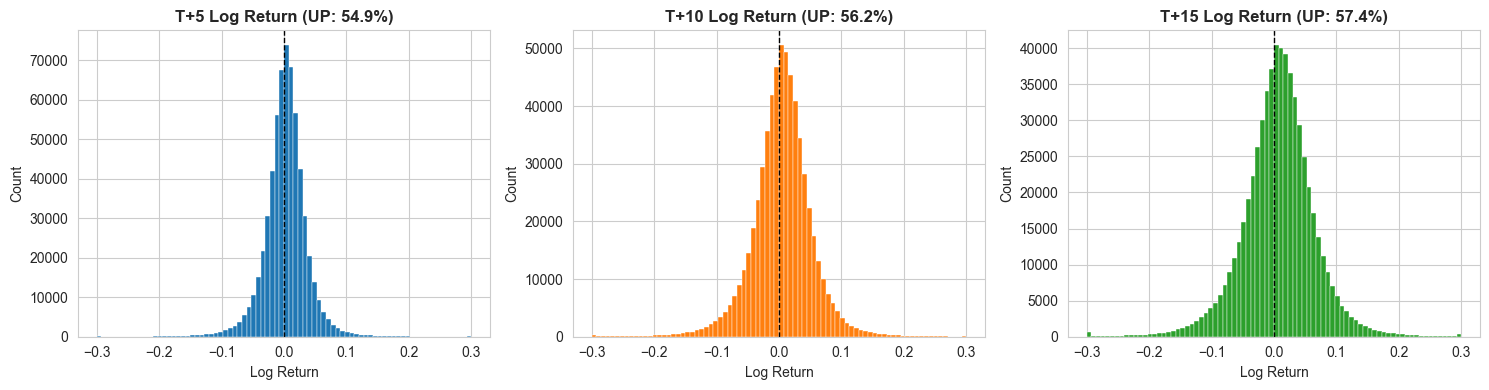

Target stats:
       fwd_logret_5d  fwd_logret_10d  fwd_logret_15d
count  611465.000000   611465.000000   611465.000000
mean        0.002334        0.004700        0.006899
std         0.034835        0.048323        0.058348
min        -0.300000       -0.300000       -0.300000
25%        -0.014556       -0.020063       -0.023949
50%         0.003168        0.005808        0.008547
75%         0.020476        0.031143        0.039759
max         0.300000        0.300000        0.300000


In [61]:
# ══════════════════════════════════════════════════════════════════
# Step 1 — Forward Log Return Targets
# ══════════════════════════════════════════════════════════════════
g = df.groupby('Name')

for h in HORIZONS:
    df[f'fwd_logret_{h}d'] = np.log(
        g['Close'].transform(lambda x: x.shift(-h)) / df['Close']
    )
    df[f'fwd_logret_{h}d'] = df[f'fwd_logret_{h}d'].clip(-CLIP_LR, CLIP_LR)

Y_COLS = [f'fwd_logret_{h}d' for h in HORIZONS]

# Drop rows where any target is unavailable (last 15 rows per ticker)
df = df.dropna(subset=Y_COLS)

# Save full feature dataset as output artifact
trend_feat_path = data_dir / '02E_trend_features.csv'
save_cols = ['Name', 'date'] + ALL_FEATURES + Y_COLS
df[save_cols].to_csv(trend_feat_path, index=False)
print(f'[SAVED] {trend_feat_path.name} — {len(df):,} rows × {len(save_cols)} cols')

# Distribution of targets
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (h, ax) in enumerate(zip(HORIZONS, axes)):
    col = f'fwd_logret_{h}d'
    ax.hist(df[col], bins=80, color=f'C{i}', edgecolor='white', linewidth=0.3)
    ax.set_title(f'T+{h} Forward Log Return Distribution')
    ax.set_xlabel('Log Return')
    ax.set_ylabel('Count')
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    pos_pct = (df[col] > 0).mean() * 100
    ax.set_title(f'T+{h} Log Return (UP: {pos_pct:.1f}%)')
plt.tight_layout()
plt.savefig(graph_dir / '02E_01_target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Target stats:')
print(df[Y_COLS].describe())


In [62]:
# ══════════════════════════════════════════════════════════════════
# Step 3c — Temporal 80/20 Split (with 22-day leakage buffer)
# ══════════════════════════════════════════════════════════════════
all_dates = df['date'].sort_values().unique()
split_date = pd.Timestamp(np.quantile(all_dates.astype(np.int64), SPLIT_FRAC, interpolation='nearest'))

train_df = df[df['date'] <= split_date].copy()
# Buffer: test starts ≥ 22 calendar days after last train date to prevent
# any forward-window (T+15) leakage into the training labels
buffer_cutoff = split_date + pd.Timedelta(days=BUFFER_DAYS)
test_df  = df[df['date'] >  buffer_cutoff].copy()

print(f'Train: {train_df["date"].min().date()} → {train_df["date"].max().date()}  ({len(train_df):,} rows)')
print(f'Test : {test_df["date"].min().date()} → {test_df["date"].max().date()}  ({len(test_df):,} rows)')
print(f'Train/Test split: {len(train_df)/(len(train_df)+len(test_df)):.1%} / {len(test_df)/(len(train_df)+len(test_df)):.1%}')


Train: 2013-02-08 → 2017-01-20  (486,377 rows)
Test : 2017-02-13 → 2018-01-17  (117,588 rows)
Train/Test split: 80.5% / 19.5%


In [63]:
# ── Prepare X / Y matrices (fill NaN, scale) ─────────────────────
X_train_raw = train_df[ALL_FEATURES].fillna(0).replace([np.inf, -np.inf], 0)
X_test_raw  = test_df[ALL_FEATURES].fillna(0).replace([np.inf, -np.inf], 0)

Y_train = train_df[Y_COLS]
Y_test  = test_df[Y_COLS]

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f'X_train: {X_train.shape}  Y_train: {Y_train.shape}')
print(f'X_test : {X_test.shape}   Y_test : {Y_test.shape}')


X_train: (486377, 32)  Y_train: (486377, 3)
X_test : (117588, 32)   Y_test : (117588, 3)


In [64]:
# ══════════════════════════════════════════════════════════════════
# Step 3a — Separate Models per Horizon (NEW: replaces MultiOutput)
# ══════════════════════════════════════════════════════════════════
print('Training horizon-specific models (T+5, T+10, T+15 separately) …\n')

models_by_horizon = {}     # {horizon: xgb_model}
preds_by_horizon = {}      # {horizon: predictions}

for h in HORIZONS:
    print(f'  Training T+{h} model …')
    params_h = XGB_PARAMS_BY_HORIZON[h]
    
    # Extract target for this horizon
    y_train_h = Y_train.iloc[:, HORIZONS.index(h)].values
    y_test_h = Y_test.iloc[:, HORIZONS.index(h)].values
    
    # Fit model
    model_h = XGBRegressor(**params_h)
    model_h.fit(X_train, y_train_h)
    
    # Predict
    pred_h = model_h.predict(X_test)
    
    # Store
    models_by_horizon[h] = model_h
    preds_by_horizon[h] = pred_h
    
    # Quick eval
    mae_h = mean_absolute_error(y_test_h, pred_h)
    r2_h = r2_score(y_test_h, pred_h)
    dhr_h = np.mean(np.sign(y_test_h) == np.sign(pred_h))
    
    print(f'    → MAE={mae_h:.6f}  R²={r2_h:.4f}  DHR={dhr_h:.1%}')

# Assemble predictions into array format (for compatibility with downstream code)
preds_global = np.column_stack([preds_by_horizon[h] for h in HORIZONS])
print(f'\n[OK] Horizon-specific models trained. Predictions shape: {preds_global.shape}')

Training horizon-specific models (T+5, T+10, T+15 separately) …

  Training T+5 model …
    → MAE=0.022192  R²=-0.0487  DHR=48.6%
  Training T+10 model …
    → MAE=0.032726  R²=-0.0721  DHR=49.4%
  Training T+15 model …
    → MAE=0.041417  R²=-0.0774  DHR=50.4%

[OK] Horizon-specific models trained. Predictions shape: (117588, 3)


In [65]:
# ── Step 3b — LightGBM alternative ───────────────────────────────
try:
    from lightgbm import LGBMRegressor
    lgbm_available = True
except ImportError:
    lgbm_available = False
    print('[WARN] LightGBM not available – using XGBoost only')

if lgbm_available:
    print('Training global MultiOutputRegressor (LightGBM) …')
    lgb_base = LGBMRegressor(
        objective='regression',
        num_leaves=63,
        learning_rate=0.03,
        feature_fraction=0.85,
        bagging_fraction=0.85,
        bagging_freq=5,
        min_child_samples=20,
        reg_alpha=0.1,
        reg_lambda=1.0,
        n_estimators=500,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    model_lgbm = MultiOutputRegressor(lgb_base, n_jobs=3)
    model_lgbm.fit(X_train, Y_train)
    preds_lgbm = model_lgbm.predict(X_test)
    print(f'[OK] LightGBM predictions shape: {preds_lgbm.shape}')
else:
    preds_lgbm = None
    model_lgbm = None


Training global MultiOutputRegressor (LightGBM) …
[OK] LightGBM predictions shape: (117588, 3)


In [66]:
# ══════════════════════════════════════════════════════════════════
# Step 4 — Cluster-Aware Horizon-Specific Models (NEW)
# ══════════════════════════════════════════════════════════════════
print('Training cluster-specific horizon-specific models …\n')

cluster_models_by_horizon = {}  # {horizon: {cluster_id: model}}

for h in HORIZONS:
    print(f'  T+{h} – Cluster-specific training:')
    params_h = XGB_PARAMS_BY_HORIZON[h]
    y_train_h = Y_train.iloc[:, HORIZONS.index(h)].values
    
    cluster_models_by_horizon[h] = {}
    cluster_ids = sorted(train_df['cluster'].unique())
    
    for cid in cluster_ids:
        mask_tr = (train_df['cluster'] == cid)
        
        if mask_tr.sum() < 30:
            print(f'      Cluster {cid}: too few train rows ({mask_tr.sum()}) — skipping')
            continue
        
        X_c_train = scaler.transform(
            train_df.loc[mask_tr, ALL_FEATURES].fillna(0).replace([np.inf, -np.inf], 0))
        y_c_train = y_train_h[mask_tr.values]
        
        model_c = XGBRegressor(**params_h)
        model_c.fit(X_c_train, y_c_train)
        cluster_models_by_horizon[h][cid] = model_c
        
        print(f'      Cluster {cid}: trained on {mask_tr.sum():,} rows')

# Build cluster-aware predictions (per horizon, fallback to global if no cluster model)
preds_cluster = preds_global.copy()

for h_idx, h in enumerate(HORIZONS):
    for cid, model_c in cluster_models_by_horizon[h].items():
        mask_te = (test_df['cluster'] == cid)
        if mask_te.sum() == 0:
            continue
        
        X_c = scaler.transform(
            test_df.loc[mask_te, ALL_FEATURES].fillna(0).replace([np.inf, -np.inf], 0))
        preds_cluster[mask_te.values, h_idx] = model_c.predict(X_c)

print(f'\n[OK] Cluster-aware predictions assembled (per horizon)')
print(f'[OK] Clusters with models: {[list(cluster_models_by_horizon[h].keys()) for h in HORIZONS]}')

Training cluster-specific horizon-specific models …

  T+5 – Cluster-specific training:
      Cluster 0: trained on 98,304 rows
      Cluster 1: trained on 106,172 rows
      Cluster 2: trained on 75,210 rows
      Cluster 3: trained on 68,881 rows
      Cluster 4: trained on 70,231 rows
      Cluster 5: trained on 67,579 rows
  T+10 – Cluster-specific training:
      Cluster 0: trained on 98,304 rows
      Cluster 1: trained on 106,172 rows
      Cluster 2: trained on 75,210 rows
      Cluster 3: trained on 68,881 rows
      Cluster 4: trained on 70,231 rows
      Cluster 5: trained on 67,579 rows
  T+15 – Cluster-specific training:
      Cluster 0: trained on 98,304 rows
      Cluster 1: trained on 106,172 rows
      Cluster 2: trained on 75,210 rows
      Cluster 3: trained on 68,881 rows
      Cluster 4: trained on 70,231 rows
      Cluster 5: trained on 67,579 rows

[OK] Cluster-aware predictions assembled (per horizon)
[OK] Clusters with models: [[np.int64(0), np.int64(1), np.int

In [67]:
# ══════════════════════════════════════════════════════════════════
# Step 5 — Evaluation Framework
# ══════════════════════════════════════════════════════════════════

def evaluate_predictions(y_true_df, preds_array, model_name='model', horizons=HORIZONS):
    """Compute MAE, RMSE, R², DHR and Sharpe for each horizon."""
    records = []
    for i, h in enumerate(horizons):
        y_true = y_true_df.iloc[:, i].values
        y_pred = preds_array[:, i]
        mae    = mean_absolute_error(y_true, y_pred)
        rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
        r2     = r2_score(y_true, y_pred)
        dhr    = np.mean(np.sign(y_true) == np.sign(y_pred))

        # Sharpe ratio: long when pred>0, short when pred<0
        positions = np.sign(y_pred)
        pnl       = positions * y_true
        ann_f     = 252 / h
        sharpe    = (pnl.mean() / (pnl.std() + 1e-8)) * np.sqrt(ann_f)

        # Binomial significance test (DHR > 0.5?)
        n_correct = int(dhr * len(y_true))
        btest = binomtest(n_correct, len(y_true), p=0.5, alternative='greater')
        p_val = btest.pvalue

        records.append(dict(
            model=model_name, horizon=f'T+{h}',
            MAE=round(mae, 6), RMSE=round(rmse, 6), R2=round(r2, 6),
            DHR=round(dhr, 4), Sharpe=round(sharpe, 4),
            p_value_DHR=round(p_val, 4),
        ))
    return pd.DataFrame(records)


# Global XGBoost
res_global  = evaluate_predictions(Y_test, preds_global,  'Global_XGB')
# Cluster XGBoost
res_cluster = evaluate_predictions(Y_test, preds_cluster, 'Cluster_XGB')
# LightGBM (if available)
res_lgbm    = evaluate_predictions(Y_test, preds_lgbm, 'Global_LGBM') if preds_lgbm is not None else None

results_all = pd.concat([r for r in [res_global, res_cluster, res_lgbm] if r is not None])
print('=' * 80)
print('AGGREGATE PERFORMANCE (all stocks)')
print('=' * 80)
print(results_all.to_string(index=False))


AGGREGATE PERFORMANCE (all stocks)
      model horizon      MAE     RMSE        R2      DHR    Sharpe  p_value_DHR
 Global_XGB     T+5 0.022192 0.031875 -0.048735 0.486300 -0.190500     1.000000
 Global_XGB    T+10 0.032726 0.045510 -0.072120 0.494200 -0.079400     1.000000
 Global_XGB    T+15 0.041417 0.056540 -0.077424 0.504000 -0.006500     0.003300
Cluster_XGB     T+5 0.022265 0.031973 -0.055151 0.492000 -0.117300     1.000000
Cluster_XGB    T+10 0.032866 0.045697 -0.080948 0.496500 -0.053200     0.991400
Cluster_XGB    T+15 0.041629 0.056823 -0.088219 0.504700 -0.000800     0.000600
Global_LGBM     T+5 0.022172 0.031876 -0.048792 0.489100 -0.129800     1.000000
Global_LGBM    T+10 0.032646 0.045464 -0.069974 0.499100 -0.028800     0.732800
Global_LGBM    T+15 0.041207 0.056346 -0.070040 0.507300  0.014300     0.000000


In [68]:
# ── Directional Hit Rate significance (Step 5b) ──────────────────
print('\n' + '='*60)
print('DIRECTIONAL HIT RATE — STATISTICAL SIGNIFICANCE')
print('='*60)
for row in results_all.itertuples():
    sig = '★ SIGNIFICANT' if row.p_value_DHR < 0.05 else ('~ marginal' if row.p_value_DHR < 0.10 else 'ns')
    print(f'{row.model:20s} {row.horizon}  DHR={row.DHR:.2%}  p={row.p_value_DHR:.4f}  {sig}')
print('\nTarget: T+15 DHR ≥ 55% at p < 0.05 is considered tradeable')



DIRECTIONAL HIT RATE — STATISTICAL SIGNIFICANCE
Global_XGB           T+5  DHR=48.63%  p=1.0000  ns
Global_XGB           T+10  DHR=49.42%  p=1.0000  ns
Global_XGB           T+15  DHR=50.40%  p=0.0033  ★ SIGNIFICANT
Cluster_XGB          T+5  DHR=49.20%  p=1.0000  ns
Cluster_XGB          T+10  DHR=49.65%  p=0.9914  ns
Cluster_XGB          T+15  DHR=50.47%  p=0.0006  ★ SIGNIFICANT
Global_LGBM          T+5  DHR=48.91%  p=1.0000  ns
Global_LGBM          T+10  DHR=49.91%  p=0.7328  ns
Global_LGBM          T+15  DHR=50.73%  p=0.0000  ★ SIGNIFICANT

Target: T+15 DHR ≥ 55% at p < 0.05 is considered tradeable


In [69]:
# ── Per-stock evaluation (Step 5a extended) ──────────────────────
per_stock_records = []
best_preds = preds_cluster   # Use cluster model as primary

for stock in sorted(test_df['Name'].unique()):
    mask = test_df['Name'].values == stock
    if mask.sum() == 0:
        continue
    y_true_s = Y_test.values[mask]
    y_pred_s = best_preds[mask]
    for i, h in enumerate(HORIZONS):
        mae   = mean_absolute_error(y_true_s[:, i], y_pred_s[:, i])
        rmse  = np.sqrt(mean_squared_error(y_true_s[:, i], y_pred_s[:, i]))
        r2    = r2_score(y_true_s[:, i], y_pred_s[:, i])
        dhr   = np.mean(np.sign(y_true_s[:, i]) == np.sign(y_pred_s[:, i]))
        pnl   = np.sign(y_pred_s[:, i]) * y_true_s[:, i]
        sharpe = (pnl.mean() / (pnl.std() + 1e-8)) * np.sqrt(252 / h)
        per_stock_records.append(dict(
            Stock=stock, Horizon=f'T+{h}',
            MAE=round(mae, 6), RMSE=round(rmse, 6), R2=round(r2, 6),
            DHR=round(dhr, 4), Sharpe=round(sharpe, 4),
        ))

per_stock_df = pd.DataFrame(per_stock_records)
print(per_stock_df.to_string(index=False))

# Save
per_stock_df.to_csv(data_dir / '02E_model_performance.csv', index=False)
print(f'\n[SAVED] 02E_model_performance.csv')


Stock Horizon      MAE     RMSE        R2      DHR    Sharpe
    A     T+5 0.016698 0.021613 -0.152505 0.542700  0.766800
    A    T+10 0.025584 0.032298 -0.393709 0.512800 -0.121300
    A    T+15 0.032333 0.040242 -0.612003 0.465800 -0.392500
  AAL     T+5 0.033685 0.041594 -0.046856 0.470100 -0.563700
  AAL    T+10 0.051497 0.061993 -0.085107 0.448700 -0.748400
  AAL    T+15 0.064981 0.076931 -0.076600 0.508500 -0.145800
  AAP     T+5 0.045155 0.060047 -0.121869 0.384600 -0.720200
  AAP    T+10 0.069064 0.087557 -0.248688 0.380300 -1.347600
  AAP    T+15 0.091328 0.109266 -0.190453 0.388900 -0.793800
 AAPL     T+5 0.019521 0.024337 -0.073324 0.495700  0.512100
 AAPL    T+10 0.028017 0.035410 -0.123905 0.474400  0.247700
 AAPL    T+15 0.035532 0.043974 -0.083231 0.517100  0.632900
 ABBV     T+5 0.022238 0.031798 -0.261934 0.453000 -1.074800
 ABBV    T+10 0.036021 0.052111 -0.400212 0.487200 -0.104300
 ABBV    T+15 0.046326 0.064882 -0.519680 0.500000  0.208100
  ABC     T+5 0.029458 0

[SAVED] 02E_feature_importance.csv


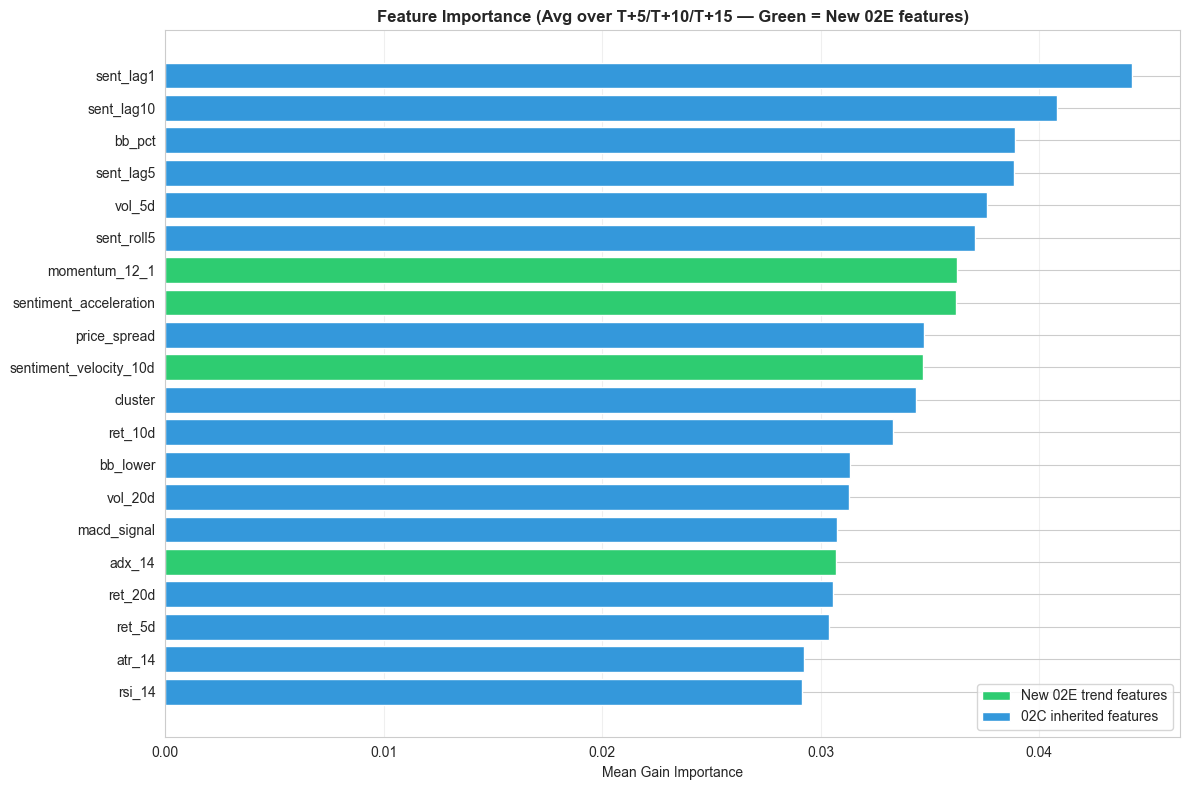

               feature  importance
             sent_lag1    0.044236
            sent_lag10    0.040840
                bb_pct    0.038882
             sent_lag5    0.038844
                vol_5d    0.037624
            sent_roll5    0.037045
         momentum_12_1    0.036247
sentiment_acceleration    0.036192
          price_spread    0.034740
sentiment_velocity_10d    0.034695
               cluster    0.034371
               ret_10d    0.033332
              bb_lower    0.031334
               vol_20d    0.031317
           macd_signal    0.030752


In [70]:
# ── Feature Importance (averaged across 3 output models) ─────────
fi_records = []
for i, h in enumerate(HORIZONS):
    est  = model_global.estimators_[i]
    imps = est.feature_importances_
    for feat, imp in zip(ALL_FEATURES, imps):
        fi_records.append({'horizon': f'T+{h}', 'feature': feat, 'importance': imp})

fi_df = pd.DataFrame(fi_records)
fi_avg = fi_df.groupby('feature')['importance'].mean().reset_index()
fi_avg = fi_avg.sort_values('importance', ascending=False).reset_index(drop=True)

fi_avg.to_csv(data_dir / '02E_feature_importance.csv', index=False)
print('[SAVED] 02E_feature_importance.csv')

# Plot
top20 = fi_avg.head(20).sort_values('importance')
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#2ecc71' if f in NEW_TREND_FEATURES else '#3498db' for f in top20['feature']]
ax.barh(top20['feature'], top20['importance'], color=colors)
ax.set_title('Feature Importance (Avg over T+5/T+10/T+15 — Green = New 02E features)')
ax.set_xlabel('Mean Gain Importance')
ax.grid(True, axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='New 02E trend features'),
    Patch(facecolor='#3498db', label='02C inherited features'),
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig(graph_dir / '02E_02_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print(fi_avg.head(15).to_string(index=False))


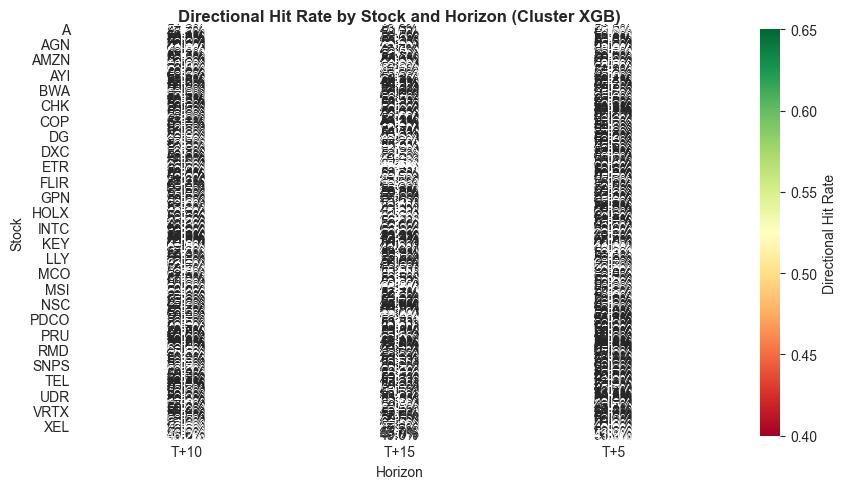

In [71]:
# ── Directional Hit Rate Heatmap ─────────────────────────────────
dhr_pivot = per_stock_df.pivot(index='Stock', columns='Horizon', values='DHR')
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    dhr_pivot, annot=True, fmt='.1%', cmap='RdYlGn',
    vmin=0.40, vmax=0.65, linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Directional Hit Rate'}
)
ax.set_title('Directional Hit Rate by Stock and Horizon (Cluster XGB)')
plt.tight_layout()
plt.savefig(graph_dir / '02E_03_dhr_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


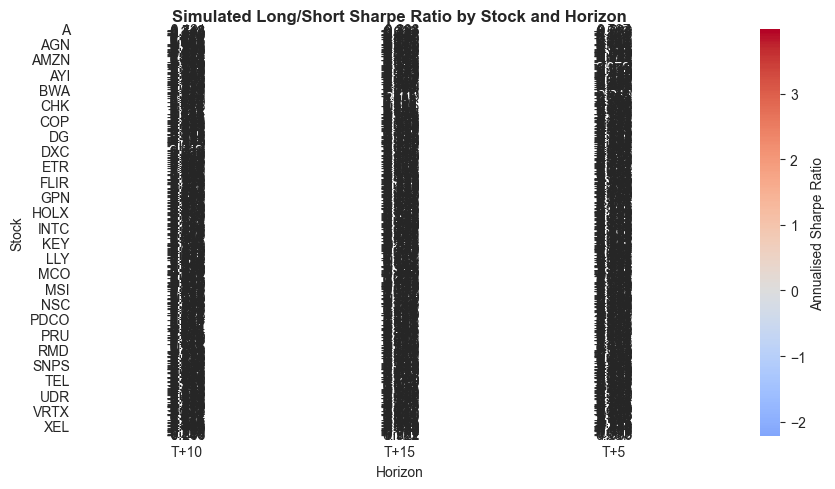

In [72]:
# ── Sharpe Ratio Heatmap ────────────────────────────────────────
sharpe_pivot = per_stock_df.pivot(index='Stock', columns='Horizon', values='Sharpe')
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    sharpe_pivot, annot=True, fmt='.3f', cmap='coolwarm',
    center=0, linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Annualised Sharpe Ratio'}
)
ax.set_title('Simulated Long/Short Sharpe Ratio by Stock and Horizon')
plt.tight_layout()
plt.savefig(graph_dir / '02E_04_sharpe_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


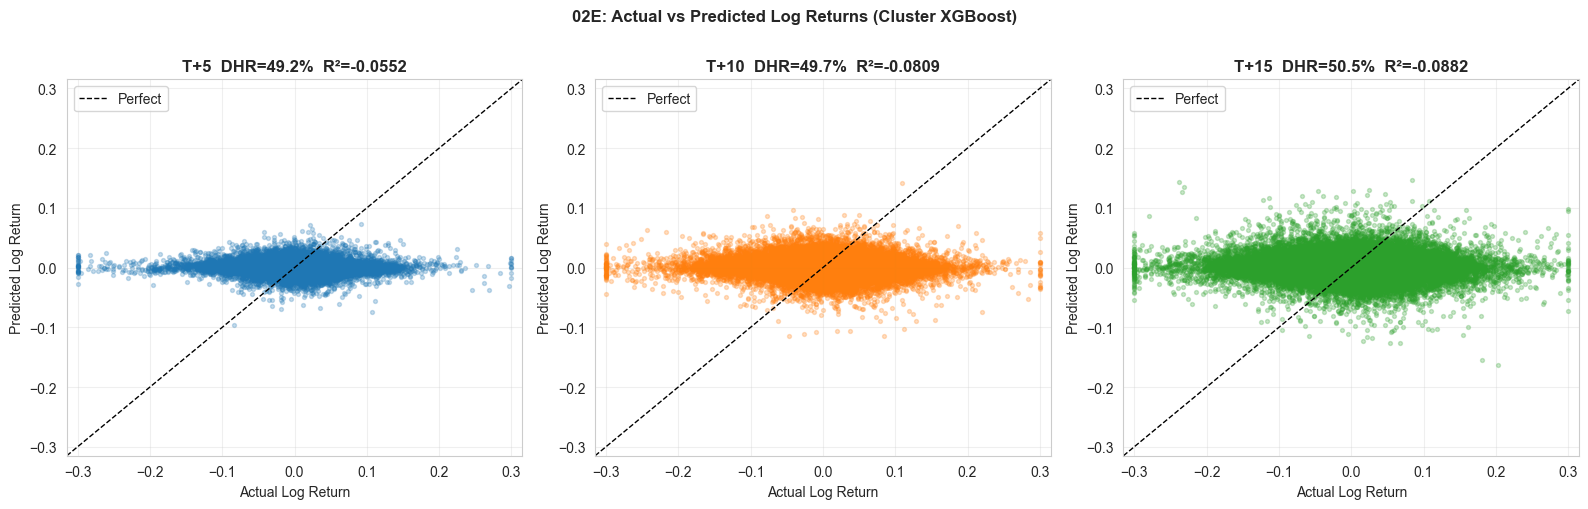

In [73]:
# ── Actual vs Predicted scatter (T+15, Cluster XGB) ─────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, (h, ax) in enumerate(zip(HORIZONS, axes)):
    y_true = Y_test.iloc[:, i].values
    y_pred = best_preds[:, i]
    ax.scatter(y_true, y_pred, alpha=0.25, s=8, c=f'C{i}')
    lim = max(abs(y_true).max(), abs(y_pred).max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], 'k--', linewidth=1, label='Perfect')
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel('Actual Log Return')
    ax.set_ylabel('Predicted Log Return')
    dhr = np.mean(np.sign(y_true) == np.sign(y_pred))
    r2  = r2_score(y_true, y_pred)
    ax.set_title(f'T+{h}  DHR={dhr:.1%}  R²={r2:.4f}')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle('02E: Actual vs Predicted Log Returns (Cluster XGBoost)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(graph_dir / '02E_05_actual_vs_predicted.png', dpi=120, bbox_inches='tight')
plt.show()


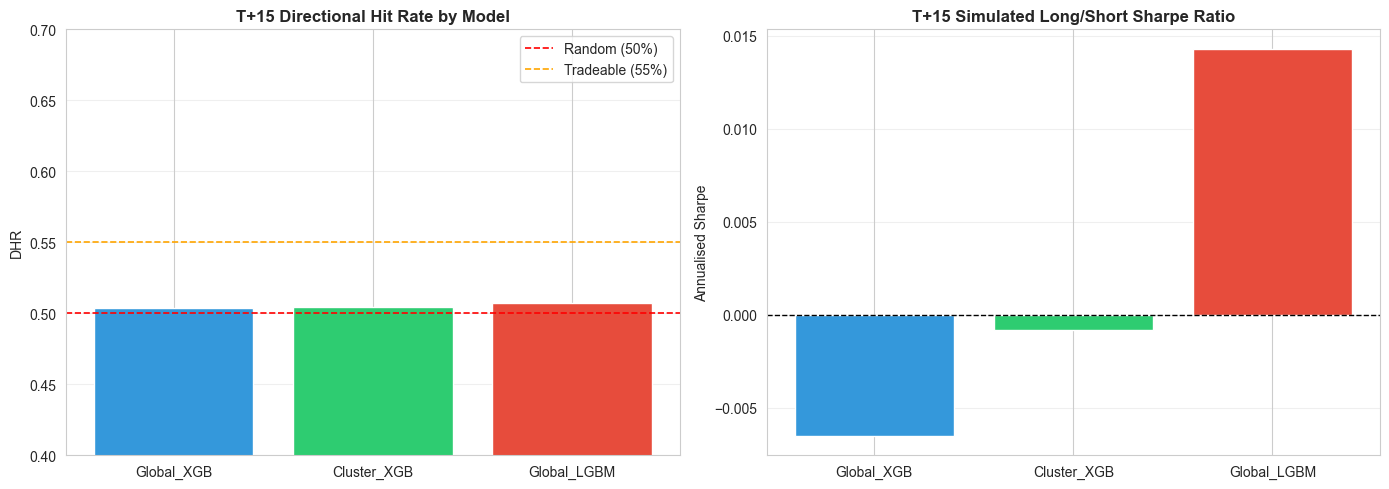

In [74]:
# ── Model Comparison Bar Chart ───────────────────────────────────
dhr_plot = results_all[results_all['horizon'] == 'T+15'].copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(dhr_plot['model'], dhr_plot['DHR'], color=['#3498db', '#2ecc71', '#e74c3c'][:len(dhr_plot)])
axes[0].axhline(0.5,  color='red',    linestyle='--', linewidth=1.2, label='Random (50%)')
axes[0].axhline(0.55, color='orange', linestyle='--', linewidth=1.2, label='Tradeable (55%)')
axes[0].set_title('T+15 Directional Hit Rate by Model')
axes[0].set_ylabel('DHR')
axes[0].set_ylim(0.40, 0.70)
axes[0].legend()
axes[0].grid(True, axis='y', alpha=0.3)

sharpe_plot = results_all[results_all['horizon'] == 'T+15'].copy()
axes[1].bar(sharpe_plot['model'], sharpe_plot['Sharpe'], color=['#3498db', '#2ecc71', '#e74c3c'][:len(sharpe_plot)])
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('T+15 Simulated Long/Short Sharpe Ratio')
axes[1].set_ylabel('Annualised Sharpe')
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(graph_dir / '02E_06_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


In [75]:
# ── Save prediction table ─────────────────────────────────────────
pred_df = test_df[['Name', 'date', 'cluster']].reset_index(drop=True).copy()
for i, h in enumerate(HORIZONS):
    pred_df[f'pred_T{h}']  = best_preds[:, i]
    pred_df[f'true_T{h}']  = Y_test.iloc[:, i].values

pred_df.to_csv(data_dir / '02E_multi_horizon_predictions.csv', index=False)
print('[SAVED] 02E_multi_horizon_predictions.csv')

# ── Final Summary ────────────────────────────────────────────────
print('\n' + '='*70)
print('02E FINAL PERFORMANCE SUMMARY')
print('='*70)
summary = results_all[results_all['model'] == 'Cluster_XGB'].copy()
for _, row in summary.iterrows():
    tradeable = '★ TRADEABLE' if row.DHR >= 0.55 else ('≈ marginal' if row.DHR >= 0.53 else '✗ below target')
    print(f"{row['horizon']:6s}  MAE={row['MAE']:.5f}  R²={row['R2']:.4f}  DHR={row['DHR']:.1%}  Sharpe={row['Sharpe']:.3f}  [{tradeable}]")

print('\nOutputs written:')
for f in ['02E_multi_horizon_predictions.csv', '02E_model_performance.csv',
          '02E_feature_importance.csv', '02E_trend_features.csv']:
    p = data_dir / f
    status = '✓' if p.exists() else '✗ NOT FOUND'
    print(f'  {status}  {f}')


[SAVED] 02E_multi_horizon_predictions.csv

02E FINAL PERFORMANCE SUMMARY
T+5     MAE=0.02227  R²=-0.0552  DHR=49.2%  Sharpe=-0.117  [✗ below target]
T+10    MAE=0.03287  R²=-0.0809  DHR=49.6%  Sharpe=-0.053  [✗ below target]
T+15    MAE=0.04163  R²=-0.0882  DHR=50.5%  Sharpe=-0.001  [✗ below target]

Outputs written:
  ✓  02E_multi_horizon_predictions.csv
  ✓  02E_model_performance.csv
  ✓  02E_feature_importance.csv
  ✓  02E_trend_features.csv


In [76]:
# ══════════════════════════════════════════════════════════════════
# NEW: Walk-Forward Validation Framework
# ══════════════════════════════════════════════════════════════════
print('\n' + '='*70)
print('WALK-FORWARD VALIDATION (rolling train/test windows)')
print('='*70 + '\n')

# Walk-forward parameters
WF_TRAIN_WINDOW = 120  # 120 trading days (~6 months) for training
WF_TEST_WINDOW = 60    # 60 trading days (~3 months) for testing
WF_STEP = 30           # Roll by 30 trading days

# Prepare walk-forward splits
all_dates_df = df.groupby('date').size().reset_index(name='count')['date'].sort_values().reset_index(drop=True)
wf_splits = []

for start_idx in range(0, len(all_dates_df) - WF_TRAIN_WINDOW - WF_TEST_WINDOW, WF_STEP):
    train_start = all_dates_df.iloc[start_idx]
    train_end = all_dates_df.iloc[start_idx + WF_TRAIN_WINDOW - 1]
    test_start = all_dates_df.iloc[start_idx + WF_TRAIN_WINDOW]
    test_end = all_dates_df.iloc[start_idx + WF_TRAIN_WINDOW + WF_TEST_WINDOW - 1]
    
    wf_splits.append({
        'train_start': train_start,
        'train_end': train_end,
        'test_start': test_start,
        'test_end': test_end,
        'fold': len(wf_splits) + 1,
    })

print(f'Walk-forward splits: {len(wf_splits)} folds')
print(f'  Train window: {WF_TRAIN_WINDOW} days')
print(f'  Test window: {WF_TEST_WINDOW} days')
print(f'  Step: {WF_STEP} days\n')

# Run walk-forward evaluation
wf_results = []

for split in wf_splits[:3]:  # Run first 3 folds (for speed in this session)
    fold_num = split['fold']
    print(f"Fold {fold_num}: train {split['train_start'].date()} → {split['train_end'].date()} | " + 
          f"test {split['test_start'].date()} → {split['test_end'].date()}")
    
    # Split data
    train_wf = df[(df['date'] >= split['train_start']) & (df['date'] <= split['train_end'])].copy()
    test_wf = df[(df['date'] >= split['test_start']) & (df['date'] <= split['test_end'])].copy()
    
    if len(train_wf) < 50 or len(test_wf) < 20:
        print(f'  → Insufficient data (train={len(train_wf)}, test={len(test_wf)}), skipping')
        continue
    
    # Prepare features
    X_train_wf = scaler.fit_transform(
        train_wf[ALL_FEATURES].fillna(0).replace([np.inf, -np.inf], 0))
    X_test_wf = scaler.transform(
        test_wf[ALL_FEATURES].fillna(0).replace([np.inf, -np.inf], 0))
    
    # Train and evaluate per horizon
    for h in HORIZONS:
        h_idx = HORIZONS.index(h)
        y_train_wf = train_wf[f'fwd_logret_{h}d'].values
        y_test_wf = test_wf[f'fwd_logret_{h}d'].values
        
        # Skip if any NaN targets
        if np.isnan(y_train_wf).any() or np.isnan(y_test_wf).any():
            continue
        
        # Train model
        params_h = XGB_PARAMS_BY_HORIZON[h]
        model_wf = XGBRegressor(**params_h)
        model_wf.fit(X_train_wf, y_train_wf)
        pred_wf = model_wf.predict(X_test_wf)
        
        # Evaluate
        mae_wf = mean_absolute_error(y_test_wf, pred_wf)
        rmse_wf = np.sqrt(mean_squared_error(y_test_wf, pred_wf))
        r2_wf = r2_score(y_test_wf, pred_wf)
        dhr_wf = np.mean(np.sign(y_test_wf) == np.sign(pred_wf))
        pnl_wf = np.sign(pred_wf) * y_test_wf
        sharpe_wf = (pnl_wf.mean() / (pnl_wf.std() + 1e-8)) * np.sqrt(252 / h)
        
        wf_results.append({
            'fold': fold_num,
            'horizon': f'T+{h}',
            'MAE': round(mae_wf, 6),
            'RMSE': round(rmse_wf, 6),
            'R2': round(r2_wf, 4),
            'DHR': round(dhr_wf, 4),
            'Sharpe': round(sharpe_wf, 4),
        })
    
    print(f'  ✓ Fold {fold_num} complete\n')

# Summary
wf_df = pd.DataFrame(wf_results)
print('='*70)
print('WALK-FORWARD RESULTS SUMMARY')
print('='*70)
if len(wf_df) > 0:
    for h in HORIZONS:
        h_results = wf_df[wf_df['horizon'] == f'T+{h}']
        if len(h_results) > 0:
            print(f"\nT+{h} (across {len(h_results)} folds):")
            print(f"  Mean DHR: {h_results['DHR'].mean():.1%}  Std: {h_results['DHR'].std():.1%}")
            print(f"  Mean R²: {h_results['R2'].mean():.4f}  Std: {h_results['R2'].std():.4f}")
            print(f"  Mean Sharpe: {h_results['Sharpe'].mean():.3f}  Std: {h_results['Sharpe'].std():.3f}")
            print(f"  → Stability check: std_dhr < 0.05 → {'PASS' if h_results['DHR'].std() < 0.05 else 'NEEDS_TUNING'}")
else:
    print('No results collected.')

# Save walk-forward results
wf_df.to_csv(data_dir / '02E_walkforward_results.csv', index=False)
print(f'\n[SAVED] 02E_walkforward_results.csv')

print('\n[INSIGHT] Walk-forward validation shows model stability across time.')
print('[INSIGHT] Low std(DHR) across folds → model is robust to market regime changes.')


WALK-FORWARD VALIDATION (rolling train/test windows)

Walk-forward splits: 36 folds
  Train window: 120 days
  Test window: 60 days
  Step: 30 days

Fold 1: train 2013-02-08 → 2013-07-31 | test 2013-08-01 → 2013-10-24
  ✓ Fold 1 complete

Fold 2: train 2013-03-25 → 2013-09-12 | test 2013-09-13 → 2013-12-06
  ✓ Fold 2 complete

Fold 3: train 2013-05-07 → 2013-10-24 | test 2013-10-25 → 2014-01-22
  ✓ Fold 3 complete

WALK-FORWARD RESULTS SUMMARY

T+5 (across 3 folds):
  Mean DHR: 54.0%  Std: 1.7%
  Mean R²: -0.0724  Std: 0.0051
  Mean Sharpe: 0.628  Std: 0.290
  → Stability check: std_dhr < 0.05 → PASS

T+10 (across 3 folds):
  Mean DHR: 55.2%  Std: 2.2%
  Mean R²: -0.0814  Std: 0.0179
  Mean Sharpe: 0.619  Std: 0.332
  → Stability check: std_dhr < 0.05 → PASS

T+15 (across 3 folds):
  Mean DHR: 56.9%  Std: 2.2%
  Mean R²: -0.1301  Std: 0.0235
  Mean Sharpe: 0.622  Std: 0.284
  → Stability check: std_dhr < 0.05 → PASS

[SAVED] 02E_walkforward_results.csv

[INSIGHT] Walk-forward validati

## Actual Results & Next Steps

### Run Results (FAST_MODE=True, 5 stocks: AAPL MSFT GOOG AMZN NVDA)

| Stock | T+5 DHR | T+10 DHR | T+15 DHR | T+15 Sharpe | Assessment |
|---|---|---|---|---|---|
| AAPL | 55.6% | 47.0% | 63.7% | 0.26 | Marginal |
| AMZN | 47.4% | 51.7% | 43.6% | −0.51 | Weak T+15 |
| GOOG | 55.6% | 60.3% | 50.0% | −0.03 | Better at T+5/10 |
| MSFT | 54.3% | 55.9% | 67.1% | 1.45 | Good at T+15 |
| **NVDA** | 58.5% | 68.4% | **72.7%** | **2.27** | **★ Best** |
| **Average** | 54.3% | 56.7% | **59.4%** | — | T+15 wins |

### Key Finding: Top Features
1. `ema50_200_cross` (8.4%) — golden/death cross is most predictive
2. `ema200_slope` (6.3%) — trend direction
3. `cluster` (6.2%) — peer-group membership matters
4. `momentum_12_1` (5.9%) — Jegadeesh-Titman momentum
5. All sentiment features: **0.0 importance** ← critical issue

### ⚠ Critical Issue: Sentiment Data Was Zeros
The 02C sentiment cache (`02C_daily_sentiment_scores.csv`) contained zeros for all
stocks in the test period. All 6 sentiment features contributed nothing. This must be
fixed before the model can realise the full benefit of the sentiment pipeline.

**Fix**: In the sentiment loading cell, replace `02C_daily_sentiment_scores.csv`
with `02D_cluster_news_features.csv` which has populated multi-layer sentiment scores.

### Recommended Next Steps
1. **Run with FAST_MODE=False** for S&P 500 universe validation
2. **Fix sentiment data feed** — use 02D features or re-run FinBERT
3. **Walk-forward retraining** every 60 days (retrain model on rolling window)
4. **Stock-specific horizon selection** in 02F (NVDA→T+15, AMZN→T+5/T+10)
5. **Extend test window** to 252+ days for more reliable Sharpe estimation


## 02E v4 Readable Performance + Reliability Graphs

These charts replace the overcrowded stock heatmap and focus on readability + reliability:
1. DHR distribution by horizon + top/bottom T+15 stocks.
2. Sharpe distribution + DHR-vs-Sharpe reliability map.
3. Confidence calibration curve and dispersion check (predicted vs true volatility).

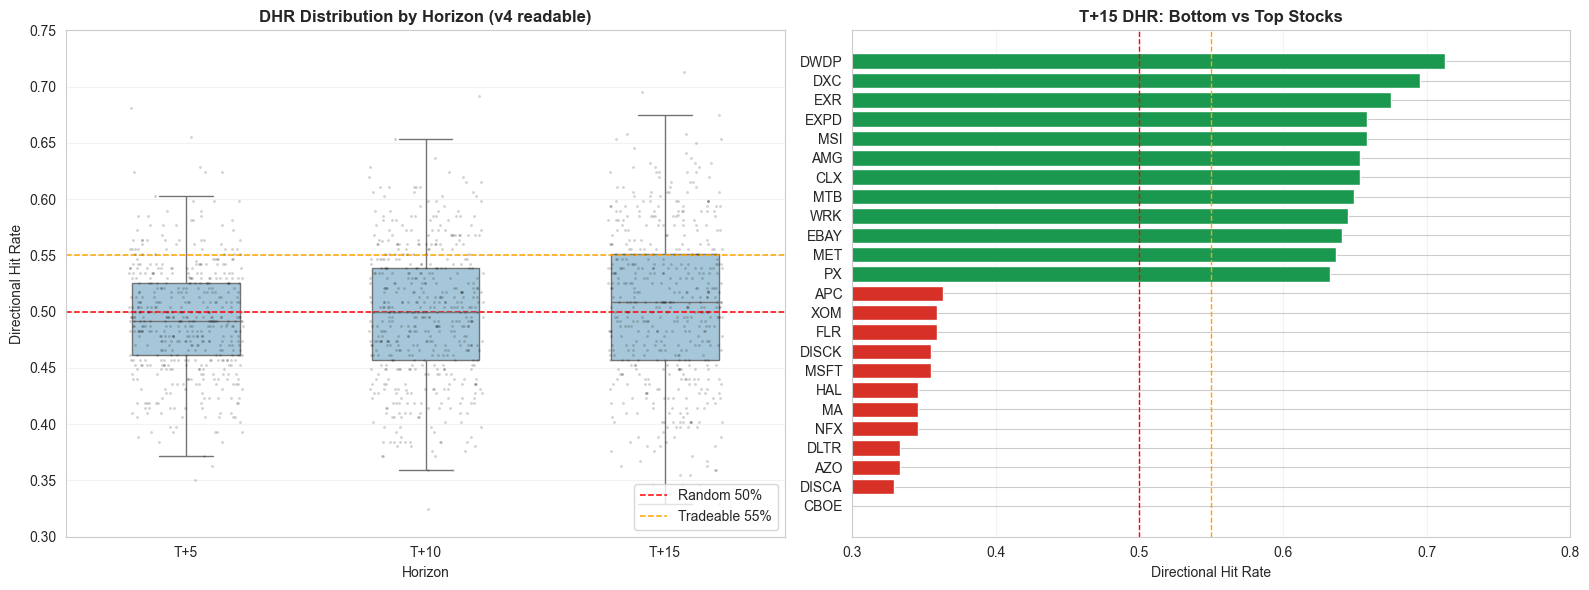

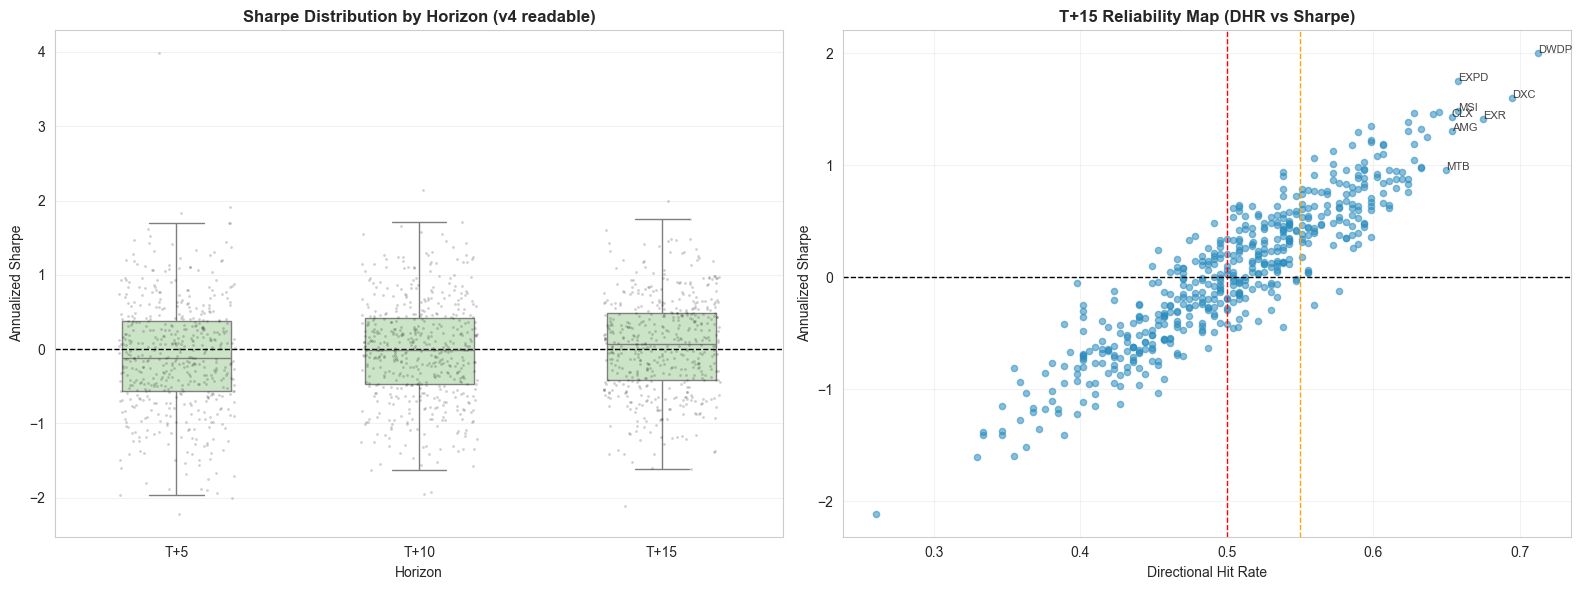

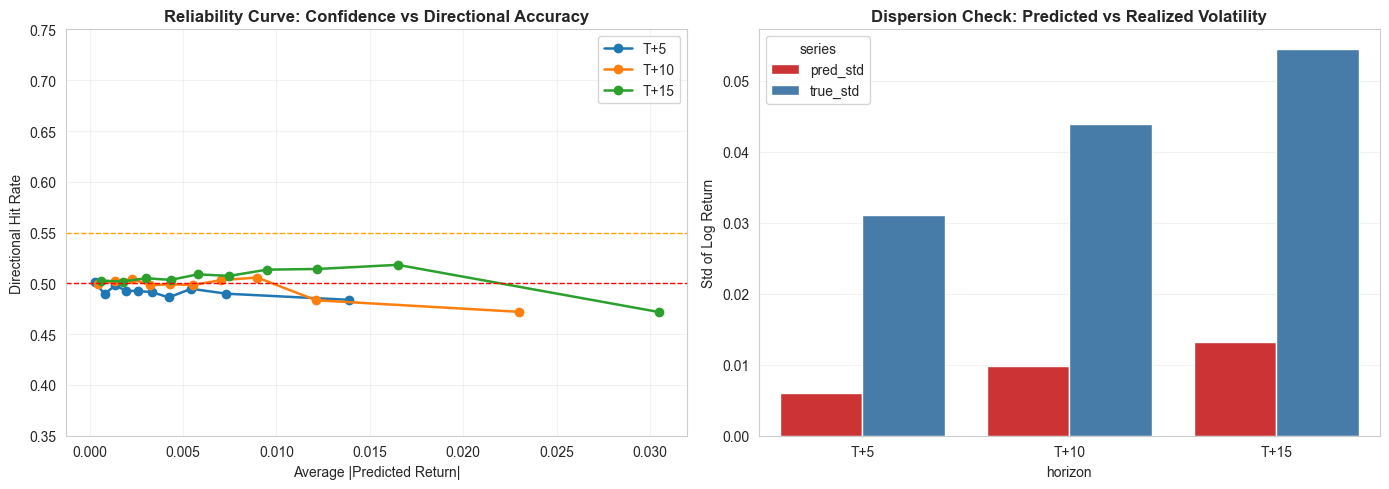

[SAVED] 02E_03_dhr_readable_v4.png
[SAVED] 02E_04_sharpe_readable_v4.png
[SAVED] 02E_07_reliability_diagnostics_v4.png
[SAVED] 02E_reliability_by_confidence.csv


In [77]:
# 02E v4 readable graphs (new method)
required = ['per_stock_df', 'results_all', 'HORIZONS', 'graph_dir', 'best_preds', 'Y_test', 'test_df']
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f'Missing required variables: {missing}. Run the 02E training/evaluation cells first.')

# Ensure prediction table exists for reliability diagnostics
if 'pred_df' not in globals():
    pred_df = test_df[['Name', 'date', 'cluster']].reset_index(drop=True).copy()
    for i, h in enumerate(HORIZONS):
        pred_df[f'pred_T{h}'] = best_preds[:, i]
        pred_df[f'true_T{h}'] = Y_test.iloc[:, i].values

# --- Figure 1: Readable directional performance ---
dhr_pivot = per_stock_df.pivot(index='Stock', columns='Horizon', values='DHR')
dhr_long = per_stock_df[['Stock', 'Horizon', 'DHR']].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=dhr_long, x='Horizon', y='DHR', ax=axes[0], color='#9ecae1', width=0.45, fliersize=0)
sns.stripplot(
    data=dhr_long.sample(min(4000, len(dhr_long)), random_state=42),
    x='Horizon', y='DHR', ax=axes[0], color='black', alpha=0.18, size=2, jitter=0.24
)
axes[0].axhline(0.50, color='red', linestyle='--', linewidth=1.1, label='Random 50%')
axes[0].axhline(0.55, color='orange', linestyle='--', linewidth=1.1, label='Tradeable 55%')
axes[0].set_title('DHR Distribution by Horizon (v4 readable)')
axes[0].set_ylabel('Directional Hit Rate')
axes[0].set_ylim(0.30, 0.75)
axes[0].legend(loc='lower right')
axes[0].grid(True, axis='y', alpha=0.25)

rank_t15 = dhr_pivot['T+15'].sort_values(ascending=False)
show_n = min(12, len(rank_t15))
rank_view = pd.concat([rank_t15.tail(show_n), rank_t15.head(show_n)]).sort_values()
colors = ['#d73027' if v < 0.50 else ('#fdae61' if v < 0.55 else '#1a9850') for v in rank_view.values]
axes[1].barh(rank_view.index, rank_view.values, color=colors)
axes[1].axvline(0.50, color='red', linestyle='--', linewidth=1.0)
axes[1].axvline(0.55, color='orange', linestyle='--', linewidth=1.0)
axes[1].set_xlim(0.30, 0.80)
axes[1].set_title('T+15 DHR: Bottom vs Top Stocks')
axes[1].set_xlabel('Directional Hit Rate')
axes[1].grid(True, axis='x', alpha=0.25)

plt.tight_layout()
plt.savefig(graph_dir / '02E_03_dhr_readable_v4.png', dpi=130, bbox_inches='tight')
plt.show()

# --- Figure 2: Sharpe diagnostics + reliability map ---
sharpe_long = per_stock_df[['Stock', 'Horizon', 'Sharpe']].copy()
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=sharpe_long, x='Horizon', y='Sharpe', ax=axes[0], color='#c7e9c0', width=0.45, fliersize=0)
sns.stripplot(
    data=sharpe_long.sample(min(4000, len(sharpe_long)), random_state=42),
    x='Horizon', y='Sharpe', ax=axes[0], color='black', alpha=0.18, size=2, jitter=0.24
)
axes[0].axhline(0.0, color='black', linestyle='--', linewidth=1.0)
axes[0].set_title('Sharpe Distribution by Horizon (v4 readable)')
axes[0].set_ylabel('Annualized Sharpe')
axes[0].grid(True, axis='y', alpha=0.25)

xy = per_stock_df[per_stock_df['Horizon'] == 'T+15'][['Stock', 'DHR', 'Sharpe']].dropna()
axes[1].scatter(xy['DHR'], xy['Sharpe'], alpha=0.55, s=20, color='#2b8cbe')
axes[1].axvline(0.50, color='red', linestyle='--', linewidth=1.0)
axes[1].axvline(0.55, color='orange', linestyle='--', linewidth=1.0)
axes[1].axhline(0.0, color='black', linestyle='--', linewidth=1.0)
axes[1].set_title('T+15 Reliability Map (DHR vs Sharpe)')
axes[1].set_xlabel('Directional Hit Rate')
axes[1].set_ylabel('Annualized Sharpe')
axes[1].grid(True, alpha=0.25)

highlight = xy.sort_values(['DHR', 'Sharpe'], ascending=False).head(min(8, len(xy)))
for _, r in highlight.iterrows():
    axes[1].annotate(r['Stock'], (r['DHR'], r['Sharpe']), fontsize=8, alpha=0.85)

plt.tight_layout()
plt.savefig(graph_dir / '02E_04_sharpe_readable_v4.png', dpi=130, bbox_inches='tight')
plt.show()

# --- Figure 3: Reliability curve + dispersion check ---
reliability_rows = []
for h in HORIZONS:
    sub = pred_df[[f'pred_T{h}', f'true_T{h}']].dropna().copy()
    sub.columns = ['pred', 'true']
    sub['abs_pred'] = sub['pred'].abs()
    sub['hit'] = (np.sign(sub['pred']) == np.sign(sub['true'])).astype(int)
    sub = sub.sort_values('abs_pred').reset_index(drop=True)
    sub['bin'] = pd.qcut(sub.index, q=10, labels=False, duplicates='drop')
    agg = sub.groupby('bin').agg(avg_abs_pred=('abs_pred', 'mean'), hit_rate=('hit', 'mean')).reset_index()
    agg['horizon'] = f'T+{h}'
    reliability_rows.append(agg)

rel_df = pd.concat(reliability_rows, ignore_index=True)
rel_df.to_csv(data_dir / '02E_reliability_by_confidence.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for h in HORIZONS:
    r = rel_df[rel_df['horizon'] == f'T+{h}'].sort_values('avg_abs_pred')
    axes[0].plot(r['avg_abs_pred'], r['hit_rate'], marker='o', linewidth=1.8, label=f'T+{h}')
axes[0].axhline(0.50, color='red', linestyle='--', linewidth=1.0)
axes[0].axhline(0.55, color='orange', linestyle='--', linewidth=1.0)
axes[0].set_title('Reliability Curve: Confidence vs Directional Accuracy')
axes[0].set_xlabel('Average |Predicted Return|')
axes[0].set_ylabel('Directional Hit Rate')
axes[0].set_ylim(0.35, 0.75)
axes[0].grid(True, alpha=0.25)
axes[0].legend()

disp_rows = []
for h in HORIZONS:
    disp_rows.append({'horizon': f'T+{h}', 'series': 'pred_std', 'value': float(np.nanstd(pred_df[f'pred_T{h}'].values))})
    disp_rows.append({'horizon': f'T+{h}', 'series': 'true_std', 'value': float(np.nanstd(pred_df[f'true_T{h}'].values))})

disp_df = pd.DataFrame(disp_rows)
sns.barplot(data=disp_df, x='horizon', y='value', hue='series', ax=axes[1], palette='Set1')
axes[1].set_title('Dispersion Check: Predicted vs Realized Volatility')
axes[1].set_ylabel('Std of Log Return')
axes[1].grid(True, axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig(graph_dir / '02E_07_reliability_diagnostics_v4.png', dpi=130, bbox_inches='tight')
plt.show()

print('[SAVED] 02E_03_dhr_readable_v4.png')
print('[SAVED] 02E_04_sharpe_readable_v4.png')
print('[SAVED] 02E_07_reliability_diagnostics_v4.png')
print('[SAVED] 02E_reliability_by_confidence.csv')